In [27]:
import numpy as np
import scipy
from ASADmodel_true import ASAD_class
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The AS-AD model we will be analyzing consist of the following 8 equations. We omit the time subscript where, $\beta _1, \beta _2, b, h, \gamma, \bar{y}, \pi^*$ are the time independent parameters:

**Goods market equilibrium** for an open economy: 

$$ y- \bar{y} = \beta _1 (e^r_{-1}+\Delta e + \pi^f-\pi)-\beta _2 (i-\pi^e_{+1} -\bar{r})+\tilde{z} \tag{1}$$

The aggregate demand are an increasing function of the real exchange rate, and demand shocks $\tilde{z}$, and a negative function of the real rate of return.

**Inflationexpectations** are defined as:

$$\pi_{+1}^e = \pi^e = \pi^f \tag{2}$$

Which says that the expected inflation are equal to the foreign inflation. 

**The taylor rule**: 

$$ i = r^f+\pi_{+1}^e+h(\pi-\pi^f)+b(y-\bar{y}), b>0 \tag{3}$$

Which describes how the Central Bank adjusts the nominal interest rate, as a response to higher/lower inflation compared to the foreign country, and positive/negative outputgap, through the parameters, h,b, respectively. This is the flexible inflation targetting version of the Taylor Rule. 

**The Uncovered Interest Parity (UIP)**: 
$$ i = i^f+\Delta e_{+1}^e \tag{4}$$

Which is an arbitrage condition, that says the return on investment from investing domestically should be equal to the return from exchanging the currency and investing foreignly and exchanging back.

**The nominal exchange rate expectations**: 

$$ \Delta e_{+1}^e = -\theta {\Delta e} \tag{5}$$

**The foreign fischer rule** or the foreign real rate: 
$$ r^f = i^f - \pi ^f \tag{6}$$

**The SRAS curve**: 
$$ \pi = \pi^e+\gamma(y-\bar{y})+s \tag{7}$$

**The real exchange rate**: 

$$e^r = e^r_{t-1} + \Delta e + \pi^f - \pi \tag{8}$$


From simple algebra, we find the three main equation of the models:

$$y_t-\bar{y} = \frac{\beta_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}e^r_{t-1} - \frac{\hat{\beta}_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}(\pi_t-\pi^f)+\frac
{1}{1+\beta_1\frac{b}{\theta} +\beta_2 b}z_t$$

$$\pi_t = \pi^f +\gamma (y_t-\bar{y})+s_t$$
$$e^r_{t} = e^r_{t-1} - (1+\frac{h}{\theta}) (\pi_t-\pi^f) -\frac{b}{\theta} (y_t-\bar{y})$$

On gap-form such that, $y-\bar{y}=\hat{y}$ and similar for $\pi$, and using $\hat{\beta}_2=1+\beta_1 \frac
{b}{\theta}+\beta_2 b$, we get:
$$\hat{y}_t = \frac{\beta_1}{\hat{\beta}_2}e^r_{t-1} - \frac{\hat{\beta}_1}{\hat{\beta}_2}\hat{\pi}+\frac
{1}{\hat{\beta}_2}z_t \tag{AD}$$
$$\hat{\pi}_t = \gamma \hat{y}_t+s_t \tag{AS}$$
$$e^r_{t} = e^r_{t-1} - (1+\frac{h}{\theta}) \hat{\pi}_t -\frac{b}{\theta} \hat{y}_t$$

These three equations describes an open economy with floating exchange rates, where the Central Bank reacts to outputgaps and inflationtarget differences, through $h$ and $b$. 

Setting $h=b=0$ we get an economy running a fixed rate policy. 

Setting $b=0$, the model collapses to an AS-AD economy with floating exchange rates and strict inflation target policy, as seen in Macroeconomics II at KU. 


**Mat Noter:**

Lad os antage, at agenterne har en opfattelse af, at der fndes et referenceniveau for valutakursen, som den forventes at returnere til over tid.

Eksempel: en dollar plejede at svare til 7 kroner, så det kommer den nok til igen.

Hvis valutakursen er over dette niveau (betegnet $\bar{e}$), forventes den derfor
at falde, og tilsvarende forventes den at stige, hvis den er under
referenceniveauet:
$$e^e_{t+1}-e_t=\theta(\bar{e}-e_t), \theta>0$$

Parameteren $\theta$ angiver hvor hurtigt valutakursen forventes at tilpasse sig efter et stød.

Referenceniveauet kan rimeligvis antages at afhænge af tidligere observationer af valutakursen. Vi kunne opskrive et udtryk hvor $\bar{e}$ afhænger af alle tidligere værdier af $e_t$, men det er besværligt, så vi kan antage at den kun påvirkes af sidste periode: 

$$\bar{e} = e_{t-1}$$

In [28]:
model = ASAD_class()
par = model.par
path = model.path

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


## 1. Single shocks

First, we model a constant demand shock happening from period 1 to period 100

In [29]:
model.shocks(1,100,1,z=True)
model.solve()

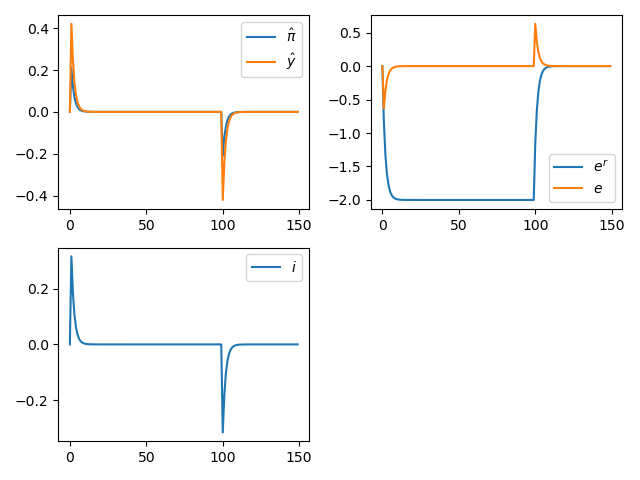

In [30]:
periods = 150 # Choose amount of periods to plot
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,3)
ax.plot(range(0,periods,1),model.path.ihat[:periods],label=r'$i$')
ax.legend(frameon=True)
fig.tight_layout()

To compare it to a situation in which the central bank does not target output, we can set b=0

In [31]:
model.par.b = 0
model.shocks(1,100,1,z=True)
model.solve()

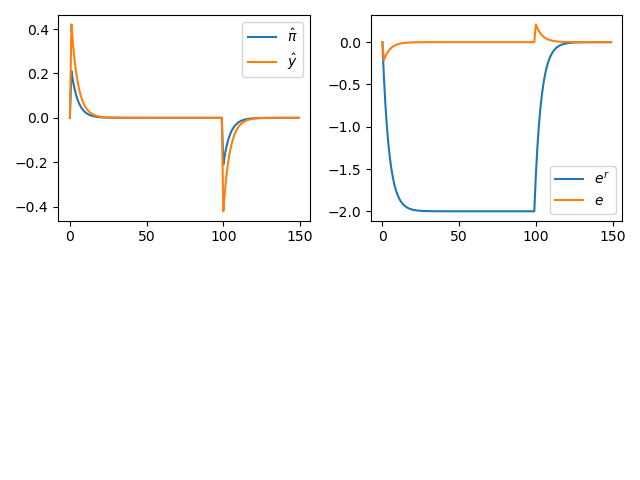

In [32]:
periods = 150 # Choose amount of periods to plot
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

The nominal exhangerate changes less, while the speed of convergence of the variables generally becomes slower. This is more so the case for the output gap than the inflation gap, since the CB is only targeting inflation. Now we turn to a negative supply shock for a similar timeframe.

In [33]:
# Reset shock variables and b
model = ASAD_class()
model.par.b = 0.5 
model.shocks(1,100,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


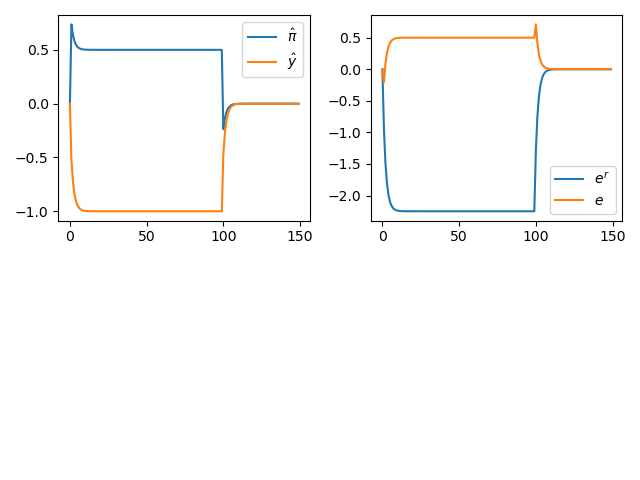

In [34]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

Since the CB mainly is able to affect the demand side of the economy, the output gap remains negative for the duration of the supply shock. The central bank lowers the interest rate as a response, to limit rising inflation. To see the importance of the size of the b parameter (how much the CB targets output), we run the shock again with b=0.9

In [35]:
# Reset shock variables and b
model = ASAD_class()
model.par.b = 0.9 
model.shocks(1,100,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


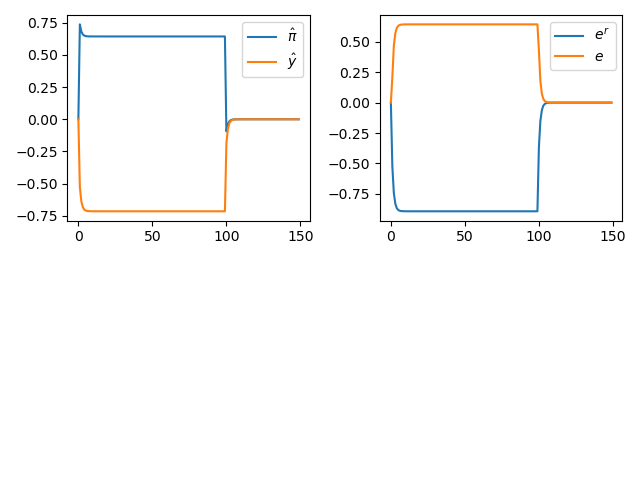

In [36]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

Output gap is still negative, but less so than for b=0.5. On the other hand, the inflation gap stays at a higher level for the duration of the shock.

(explain intuition)

## 2. Stochastic Shocks

In [37]:
# Reset shock variables
model = ASAD_class()
model.par.b = 0.5 
# Load stochastic shocks and solve model
model.stochastic_shocks(0,1,z=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


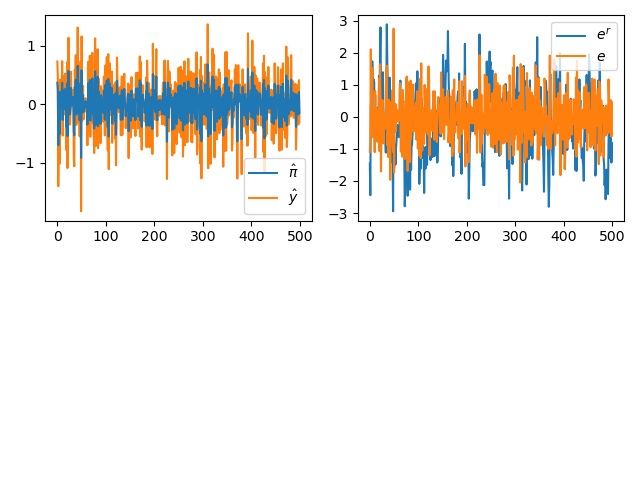

In [38]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$', zorder=10)
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

In [39]:
# Reset shock variables
model = ASAD_class()
# Load stochastic shocks and solve model
model.stochastic_shocks(0,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


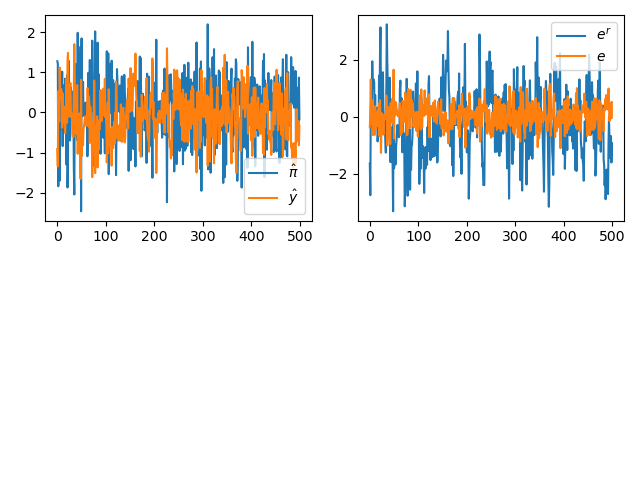

In [40]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 3. Persistent, stochastic shocks (AR)

### Demand shocks as an AR-process

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


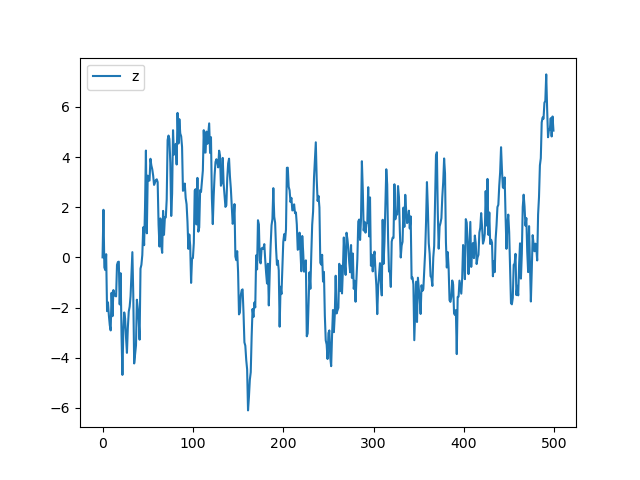

In [41]:
# Reset shock variables
model = ASAD_class()
# Load stochastic AR shocks and plot them
model.AR_shocks(rho=0.9,sd=1,z=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r'z')
ax.legend(frameon=True)

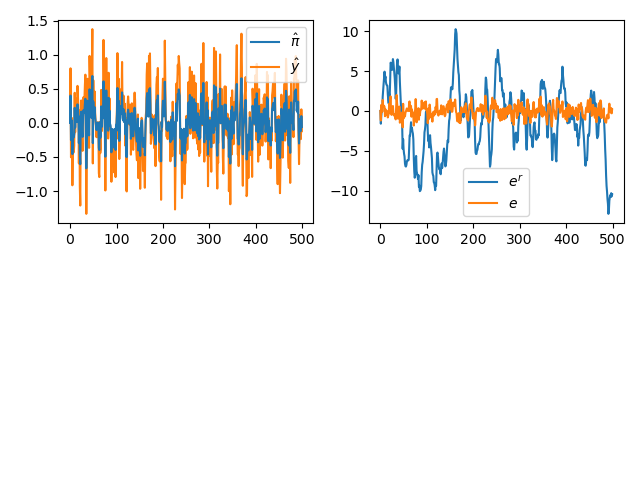

In [42]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$', zorder=10)
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')

ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

### Supply shocks as an AR-process

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


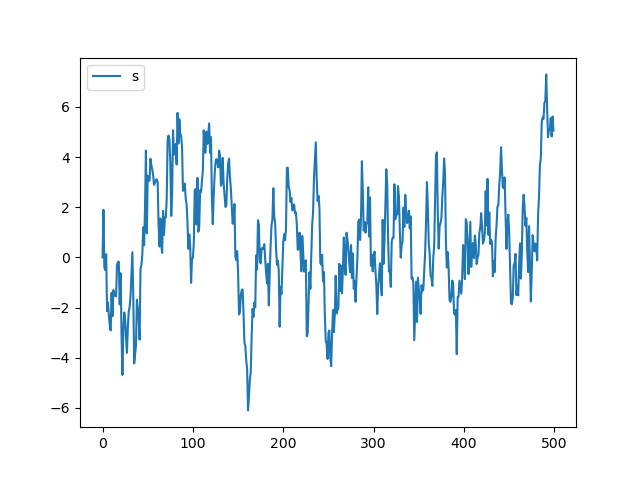

In [43]:
# Reset shock variables
model = ASAD_class()
# Supply AR shock
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.s,label=r's')
ax.legend(frameon=True)

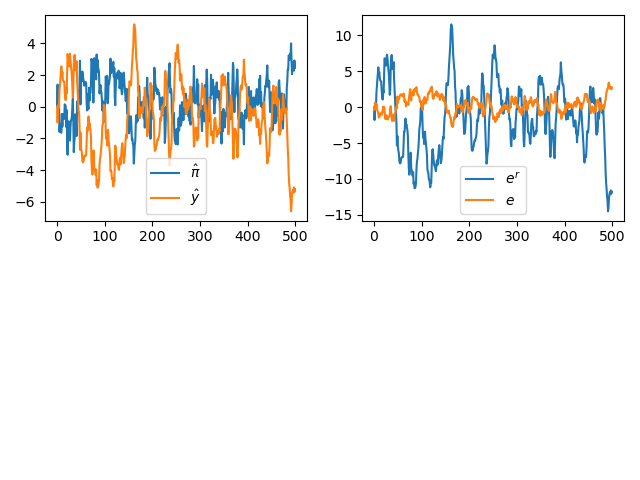

In [44]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 4. The super, social planner, living in an AR-world

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


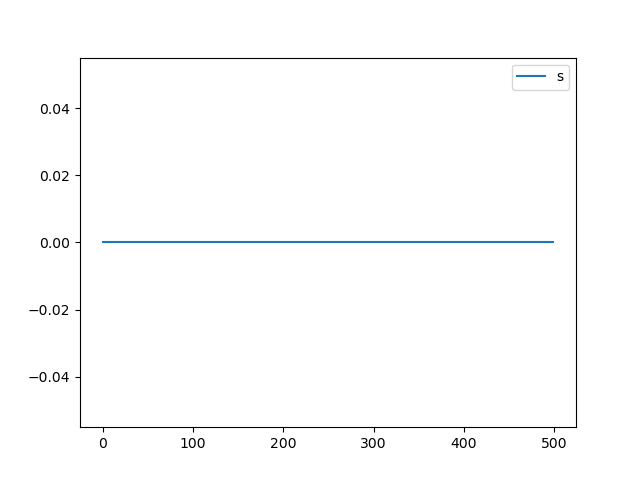

In [45]:
# Reset shock variables
model = ASAD_class()
# AR supply shock
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.s,label=r's')
ax.legend(frameon=True)

In [46]:
sl = np.zeros((20,20))
possible_h = np.linspace(0,2,num=20)
possible_b = np.linspace(0,2,num=20)

def slhb(x):
    h, b = x
    model.par.h = h
    model.par.b = b
    model.solve()
    return model.compute_social_loss()

In [47]:
sl_best = np.inf
h_best = np.nan
b_best = np.nan

# Create a matrix to store the results
sl = np.zeros((len(possible_h), len(possible_b)))

for i, h in enumerate(possible_h):
    for j, b in enumerate(possible_b):
        x = np.array([h, b])
        sl_value = slhb(x)  # Compute social loss for (h, b)
        sl[i, j] = sl_value
        
        if sl_value < sl_best:
            sl_best = sl_value
            h_best = h
            b_best = b

print(h_best, b_best, sl_best)

0.0 0.0 0.0


In [48]:
# Alternative using a solver
x_init = np.array([0,0])
social_loss = scipy.optimize.minimize(slhb,x0=x_init, method='nelder-mead')

In [49]:
# Access the optimized parameters
optimized_parameters = social_loss.x
print("Optimized parameters (h, b):", optimized_parameters)

# Access the minimum value of the objective function
min_loss = social_loss.fun
print("Minimum value of the objective function:", min_loss)

Optimized parameters (h, b): [0. 0.]
Minimum value of the objective function: 0.0


The cell below calculates social loss for a larger grid (50x50), so it takes a while to load. Makes it easier to see the slopes of the surfaceplot

In [50]:
# Generate values for h and b
h_values = np.linspace(0, 2, num=50)
b_values = np.linspace(0, 2, num=50)

# Create a grid of h and b values
H, B = np.meshgrid(h_values, b_values)

# Compute the social loss for each combination of h and b
social_loss_values = np.zeros_like(H)
for i in range(len(h_values)):
    for j in range(len(b_values)):
        model.par.h = H[i, j]
        model.par.b = B[i, j]
        model.solve()
        social_loss_values[i, j] = model.compute_social_loss()



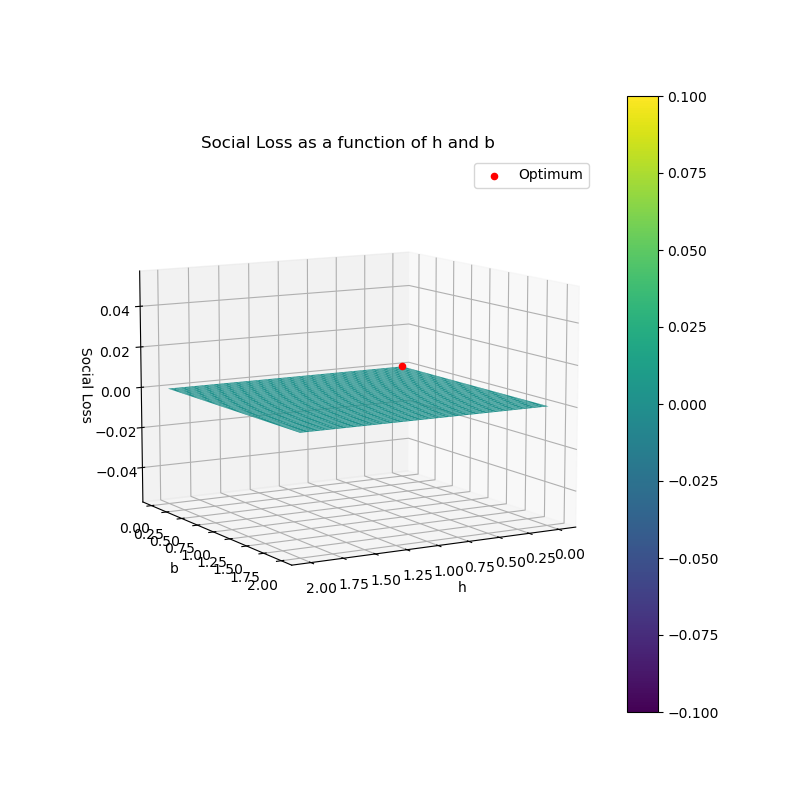

In [51]:
# Plot the surface
%matplotlib ipympl
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
surf = ax.plot_surface(H, B, social_loss_values, cmap='viridis')
# Plot optimum point
ax.scatter(optimized_parameters[0], optimized_parameters[1], min_loss, color='red', label='Optimum', s=20)
# Set labels and title
ax.set_xlabel('h')
ax.set_ylabel('b')
ax.set_zlabel('Social Loss')
ax.set_title('Social Loss as a function of h and b')

fig.colorbar(surf)
ax.legend()

ax.view_init(elev=10, azim=60)
plt.show()